11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Taille entraînement : (60000, 28, 28)
Taille test : (10000, 28, 28)


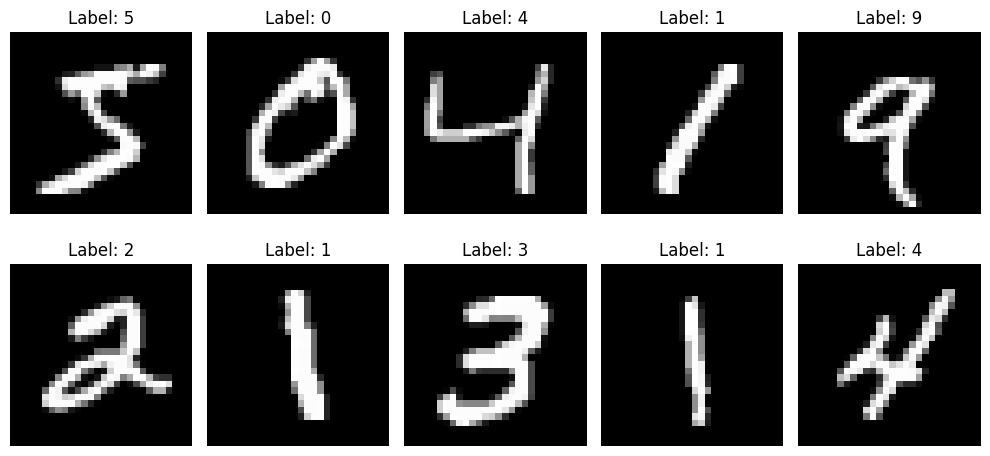

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9238 - loss: 0.2595 - val_accuracy: 0.9624 - val_loss: 0.1289
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9671 - loss: 0.1095 - val_accuracy: 0.9638 - val_loss: 0.1176
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9768 - loss: 0.0757 - val_accuracy: 0.9665 - val_loss: 0.1063
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9823 - loss: 0.0565 - val_accuracy: 0.9714 - val_loss: 0.1000
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9859 - loss: 0.0437 - val_accuracy: 0.9665 - val_loss: 0.1196
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9739 - val_loss: 0.1020
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9905 - loss: 0.0292 - val_accuracy: 0.9734 - val_loss: 0.1107
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9917 - loss: 0.0245 

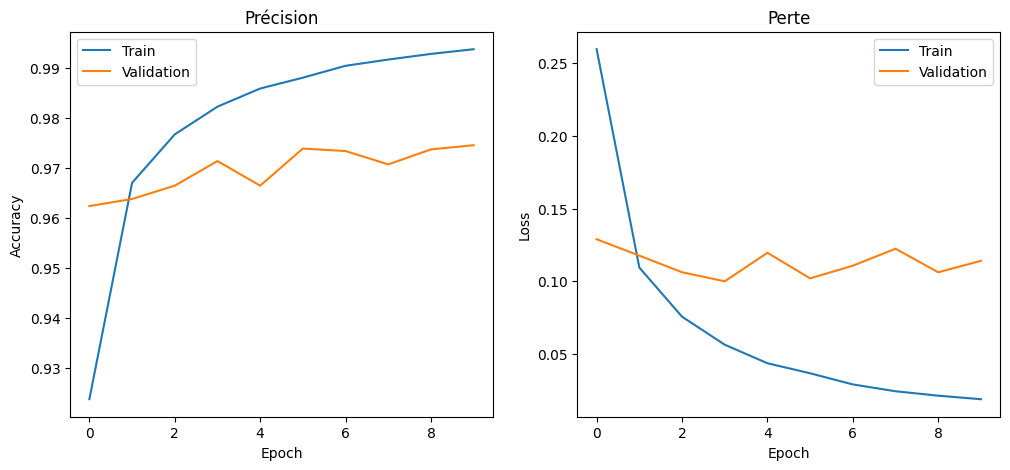

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.1023

Précision sur le jeu de test : 0.9759
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 800x800 with 0 Axes>

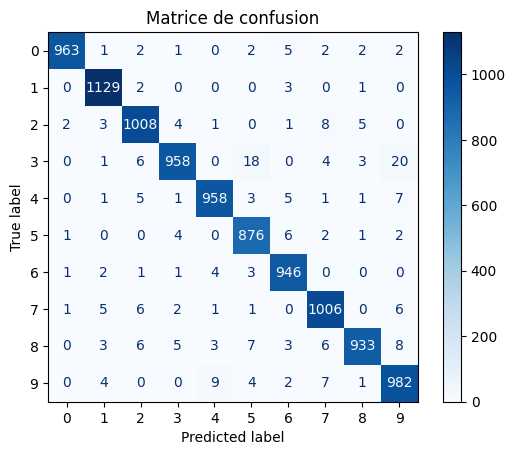

Nombre total d'erreurs : 241


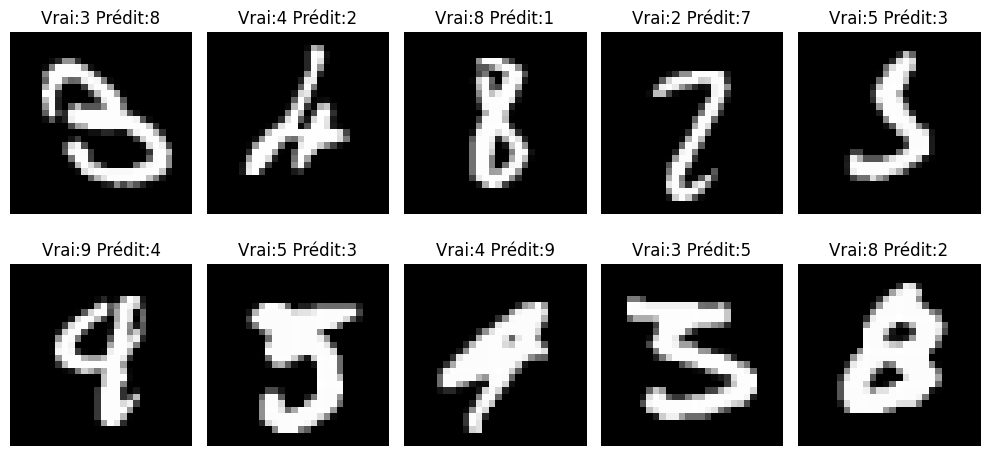

In [1]:
# Importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Charger et prétraiter MNIST

# Chargement des données
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalisation des pixels (0 à 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Encodage One-Hot des étiquettes
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Taille entraînement :", x_train.shape)
print("Taille test :", x_test.shape)

# Affichage de quelques images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 2. Construire le réseau neuronal

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Résumé du modèle
model.summary()

# 3. Entraîner le réseau neuronal

history = model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Courbes de précision et perte
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Perte')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 4. Évaluation du modèle

test_loss, test_acc = model.evaluate(x_test, y_test_cat)

print(f"\nPrécision sur le jeu de test : {test_acc:.4f}")

# Prédictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

# Identifier les erreurs
errors = np.where(y_test != y_pred_classes)[0]

print(f"Nombre total d'erreurs : {len(errors)}")

# Affichage de quelques erreurs
plt.figure(figsize=(10,5))
for i, idx in enumerate(errors[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Vrai:{y_test[idx]} Prédit:{y_pred_classes[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()